In [1]:
# 1. Install dependencies and clone the official Microsoft CvT repository
!pip install -q timm einops scipy pyyaml

import os, sys, subprocess

if not os.path.exists("/content/CvT"):
    !git clone https://github.com/microsoft/CvT.git /content/CvT

sys.path.insert(0, "/content/CvT")

print("CvT repository ready.")


Cloning into '/content/CvT'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 83 (delta 17), reused 8 (delta 8), pack-reused 49 (from 1)
Receiving objects: 100% (83/83), 161.18 KiB | 877.00 KiB/s, done.
Resolving deltas: 100% (21/21), done.
CvT repository ready.


In [2]:
# 2. Imports and reproducibility
import os
import glob
import zipfile
import shutil
import random
import copy
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

print("PyTorch:", torch.__version__)
print("Seed:", SEED)


PyTorch: 2.11.0+cu128
Seed: 42


In [3]:
# 3. GPU check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not enabled. In Colab use Runtime > Change runtime type > GPU.")


Device: cuda
GPU: Tesla T4


In [4]:
# 4. Upload ZIP
from google.colab import files

uploaded = files.upload()


Saving New_dataset.zip to New_dataset.zip


In [5]:
# 5. Extract the uploaded ZIP
zip_files = glob.glob("/content/*.zip")

if not zip_files:
    raise FileNotFoundError("No ZIP file found. Please upload your dataset ZIP.")

zip_path = zip_files[0]
extract_path = "/content/fake_news_dataset"

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Location:", extract_path)


Dataset extracted successfully!
Location: /content/fake_news_dataset


In [6]:
# 6. Find all Fake/Real image folders and collect images
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def collect_image_paths(root):
    records = []

    for current_root, dirs, files in os.walk(root):
        folder = os.path.basename(current_root).lower()

        if folder not in {"fake", "real"}:
            continue

        label = 0 if folder == "fake" else 1

        for fname in files:
            if Path(fname).suffix.lower() in IMAGE_EXTENSIONS:
                records.append({
                    "path": os.path.join(current_root, fname),
                    "label": label,
                    "label_name": "Fake" if label == 0 else "Real"
                })

    return pd.DataFrame(records)

df = collect_image_paths(extract_path)

if len(df) == 0:
    raise RuntimeError(
        "No Fake/Real images were found. Check that your ZIP contains folders named Fake and Real."
    )

print("Total images:", len(df))
print("\nClass distribution:")
print(df["label_name"].value_counts())

display(df.head())


Total images: 995

Class distribution:
label_name
Fake    498
Real    497
Name: count, dtype: int64


,path,label,label_name
0,/content/fake_news_dataset/New_dataset/test/Fa...,0,Fake
1,/content/fake_news_dataset/New_dataset/test/Fa...,0,Fake
2,/content/fake_news_dataset/New_dataset/test/Fa...,0,Fake
3,/content/fake_news_dataset/New_dataset/test/Fa...,0,Fake
4,/content/fake_news_dataset/New_dataset/test/Fa...,0,Fake


In [7]:
# 7. Check corrupted/unreadable images
bad_files = []

for path in df["path"]:
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception:
        bad_files.append(path)

print("Corrupted/unreadable images:", len(bad_files))

if bad_files:
    df = df[~df["path"].isin(bad_files)].reset_index(drop=True)
    print("Removed corrupted images.")
else:
    print("No corrupted images found.")

print("Usable images:", len(df))
print(df["label_name"].value_counts())


Corrupted/unreadable images: 0
No corrupted images found.
Usable images: 995
label_name
Fake    498
Real    497
Name: count, dtype: int64


DATASET SUMMARY
Total images: 995
Fake: 498
Real: 497


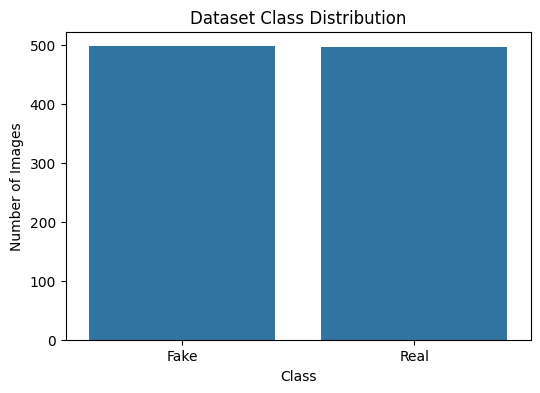

In [8]:
# 8. Dataset summary
print("=" * 55)
print("DATASET SUMMARY")
print("=" * 55)
print("Total images:", len(df))
print("Fake:", int((df.label == 0).sum()))
print("Real:", int((df.label == 1).sum()))
print("=" * 55)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label_name")
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


In [9]:
# 9. Image transforms
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms ready.")


Transforms ready.


In [10]:
# 10. PyTorch Dataset
class FakeNewsImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = Image.open(row["path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(int(row["label"]), dtype=torch.long)
        return image, label

print("Dataset class ready.")


Dataset class ready.


In [11]:
# 11. Compatibility patch for the official Microsoft CvT source

model_file = "/content/CvT/lib/models/cls_cvt.py"

with open(model_file, "r", encoding="utf-8") as f:
    content = f.read()

# PyTorch removed torch._six. The original CvT code uses
# container_abcs.Iterable, so replace it with collections.abc.Iterable.
content = content.replace(
    "from torch._six import container_abcs",
    "from collections.abc import Iterable"
)

content = content.replace(
    "from collections.abc import Iterable as container_abcs",
    "from collections.abc import Iterable"
)

content = content.replace(
    "container_abcs.Iterable",
    "Iterable"
)

with open(model_file, "w", encoding="utf-8") as f:
    f.write(content)

print("CvT Python compatibility patch applied.")

sys.path.insert(0, "/content/CvT")

import importlib
import lib.models.cls_cvt as cls_cvt
importlib.reload(cls_cvt)

from lib.models.cls_cvt import VisionTransformer

print("Official CvT VisionTransformer imported successfully.")


CvT Python compatibility patch applied.


/content/CvT/lib/models/cls_cvt.py:557: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  or pretrained_layers[0] is '*'


Official CvT VisionTransformer imported successfully.


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [15]:
# ============================================================
# CELL 13 — CvT-13 MULTI-STAGE CLASSIFIER — FIXED
# ============================================================

import importlib
import torch
import torch.nn as nn

import lib.models.cls_cvt as cls_cvt
importlib.reload(cls_cvt)

ConvEmbed = cls_cvt.ConvEmbed
Block = cls_cvt.Block


# ============================================================
# CvT STAGE
# ============================================================

class CvTStage(nn.Module):

    def __init__(
        self,
        in_chans,
        embed_dim,
        patch_size,
        patch_stride,
        patch_padding,
        depth,
        num_heads,
        drop_path_rates,
        with_cls_token=False
    ):

        super().__init__()

        self.with_cls_token = with_cls_token

        # Convolutional token embedding
        self.patch_embed = ConvEmbed(
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            stride=patch_stride,
            padding=patch_padding,
            norm_layer=nn.LayerNorm
        )

        # CLS token ONLY for final stage
        if with_cls_token:

            self.cls_token = nn.Parameter(
                torch.zeros(
                    1,
                    1,
                    embed_dim
                )
            )

            nn.init.trunc_normal_(
                self.cls_token,
                std=0.02
            )

        # Transformer blocks
        self.blocks = nn.ModuleList()

        for i in range(depth):

            self.blocks.append(
                Block(
                    dim_in=embed_dim,
                    dim_out=embed_dim,
                    num_heads=num_heads,
                    mlp_ratio=4.0,
                    qkv_bias=False,
                    drop=0.0,
                    attn_drop=0.0,
                    drop_path=drop_path_rates[i],
                    norm_layer=nn.LayerNorm,
                    with_cls_token=with_cls_token,
                    method="dw_bn",
                    kernel_size=3,
                    stride_kv=2,
                    stride_q=1,
                    padding_kv=1,
                    padding_q=1
                )
            )

        self.norm = nn.LayerNorm(
            embed_dim
        )


    def forward(self, x):

        # ----------------------------------------------------
        # Convolutional embedding
        # ----------------------------------------------------

        x = self.patch_embed(x)

        B, C, H, W = x.shape

        # Feature map -> tokens
        x = x.flatten(2).transpose(1, 2)


        # ----------------------------------------------------
        # Add CLS token only when required
        # ----------------------------------------------------

        if self.with_cls_token:

            cls_token = self.cls_token.expand(
                B,
                -1,
                -1
            )

            x = torch.cat(
                [cls_token, x],
                dim=1
            )


        # ----------------------------------------------------
        # Transformer blocks
        # ----------------------------------------------------

        for block in self.blocks:

            x = block(
                x,
                H,
                W
            )

        x = self.norm(x)


        # ----------------------------------------------------
        # Separate CLS and spatial tokens
        # ----------------------------------------------------

        if self.with_cls_token:

            cls_token = x[:, :1, :]
            tokens = x[:, 1:, :]

        else:

            cls_token = None
            tokens = x


        # ----------------------------------------------------
        # Tokens -> feature map
        # ----------------------------------------------------

        tokens = tokens.transpose(
            1,
            2
        )

        tokens = tokens.reshape(
            B,
            C,
            H,
            W
        )

        return tokens, cls_token


# ============================================================
# CvT-13 CLASSIFIER
# ============================================================

class CvT13Classifier(nn.Module):

    def __init__(
        self,
        num_classes=2
    ):

        super().__init__()


        # ====================================================
        # Drop-path schedule
        # ====================================================

        total_depth = 1 + 2 + 10

        dpr = torch.linspace(
            0.0,
            0.1,
            total_depth
        ).tolist()


        # ====================================================
        # STAGE 1
        # ====================================================
        # 3 -> 64
        # Depth = 1
        # Heads = 1
        # NO CLS TOKEN

        self.stage1 = CvTStage(

            in_chans=3,

            embed_dim=64,

            patch_size=7,

            patch_stride=4,

            patch_padding=2,

            depth=1,

            num_heads=1,

            drop_path_rates=dpr[0:1],

            with_cls_token=False
        )


        # ====================================================
        # STAGE 2
        # ====================================================
        # 64 -> 192
        # Depth = 2
        # Heads = 3
        # NO CLS TOKEN

        self.stage2 = CvTStage(

            in_chans=64,

            embed_dim=192,

            patch_size=3,

            patch_stride=2,

            patch_padding=1,

            depth=2,

            num_heads=3,

            drop_path_rates=dpr[1:3],

            with_cls_token=False
        )


        # ====================================================
        # STAGE 3
        # ====================================================
        # 192 -> 384
        # Depth = 10
        # Heads = 6
        # CLS TOKEN ENABLED

        self.stage3 = CvTStage(

            in_chans=192,

            embed_dim=384,

            patch_size=3,

            patch_stride=2,

            patch_padding=1,

            depth=10,

            num_heads=6,

            drop_path_rates=dpr[3:13],

            with_cls_token=True
        )


        # ====================================================
        # CLASSIFICATION HEAD
        # ====================================================

        self.head = nn.Linear(
            384,
            num_classes
        )

        nn.init.trunc_normal_(
            self.head.weight,
            std=0.02
        )

        nn.init.zeros_(
            self.head.bias
        )


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(self, x):

        # Stage 1
        x, _ = self.stage1(x)

        # Stage 2
        x, _ = self.stage2(x)

        # Stage 3
        x, cls_token = self.stage3(x)

        # Final CLS representation
        features = cls_token[:, 0, :]

        # Fake / Real logits
        logits = self.head(features)

        return logits


# ============================================================
# MODEL CREATION FUNCTION
# ============================================================

def create_cvt13_model(num_classes=2):

    return CvT13Classifier(
        num_classes=num_classes
    )


# ============================================================
# MODEL VERIFICATION
# ============================================================

try:

    test_model = create_cvt13_model(
        num_classes=2
    ).to(device)

    total_params = sum(
        p.numel()
        for p in test_model.parameters()
    )

    trainable_params = sum(
        p.numel()
        for p in test_model.parameters()
        if p.requires_grad
    )

    print("=" * 70)
    print("CvT-13 MODEL VERIFICATION")
    print("=" * 70)

    print(
        "Total parameters:",
        f"{total_params:,}"
    )

    print(
        "Trainable parameters:",
        f"{trainable_params:,}"
    )


    # Dummy input
    dummy_input = torch.randn(
        2,
        3,
        224,
        224,
        device=device
    )

    test_model.eval()


    with torch.no_grad():

        dummy_output = test_model(
            dummy_input
        )


    print(
        "Dummy input shape :",
        dummy_input.shape
    )

    print(
        "Model output shape:",
        dummy_output.shape
    )


    # Must be [batch, 2]
    assert dummy_output.shape == (
        2,
        2
    ), (
        f"Expected output [2, 2], "
        f"but got {dummy_output.shape}"
    )


    print()
    print("Output shape check PASSED.")
    print(
        "CvT-13 is ready for Fake / Real classification."
    )

    print("=" * 70)


    # Cleanup
    del test_model
    del dummy_input
    del dummy_output

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


except Exception as e:

    print("CvT-13 verification failed:")
    print(type(e).__name__, ":", e)

    raise

CvT-13 MODEL VERIFICATION
Total parameters: 19,600,898
Trainable parameters: 19,600,898
Dummy input shape : torch.Size([2, 3, 224, 224])
Model output shape: torch.Size([2, 2])

Output shape check PASSED.
CvT-13 is ready for Fake / Real classification.


In [16]:
# FIX: Reload the patched official Microsoft CvT module

model_file = "/content/CvT/lib/models/cls_cvt.py"

with open(model_file, "r", encoding="utf-8") as f:
    content = f.read()

content = content.replace(
    "from torch._six import container_abcs",
    "from collections.abc import Iterable"
)

content = content.replace(
    "from collections.abc import Iterable as container_abcs",
    "from collections.abc import Iterable"
)

content = content.replace(
    "container_abcs.Iterable",
    "Iterable"
)

with open(model_file, "w", encoding="utf-8") as f:
    f.write(content)

import importlib
import lib.models.cls_cvt as cls_cvt

importlib.reload(cls_cvt)

from lib.models.cls_cvt import VisionTransformer

print("VisionTransformer reloaded successfully.")


VisionTransformer reloaded successfully.


/content/CvT/lib/models/cls_cvt.py:557: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  or pretrained_layers[0] is '*'


In [17]:
# 13. IMPORTANT: verify the model constructor AND output shape

try:
    test_model = create_cvt13_model(num_classes=2).to(device)

    total_params = sum(
        p.numel()
        for p in test_model.parameters()
    )

    trainable_params = sum(
        p.numel()
        for p in test_model.parameters()
        if p.requires_grad
    )

    print("CvT-13 created successfully.")
    print("Total parameters:", f"{total_params:,}")
    print("Trainable parameters:", f"{trainable_params:,}")

    # Test the actual forward pass
    dummy_input = torch.randn(
        2, 3, 224, 224,
        device=device
    )

    test_model.eval()

    with torch.no_grad():
        dummy_output = test_model(dummy_input)

    print("Dummy input shape :", dummy_input.shape)
    print("Model output shape:", dummy_output.shape)

    assert dummy_output.shape == (2, 2), (
        f"Expected model output [2, 2], "
        f"but received {dummy_output.shape}"
    )

    print("Output shape check PASSED.")
    print("CvT-13 is ready for Fake / Real classification.")

    del test_model, dummy_input, dummy_output

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

except Exception as e:
    print("CvT-13 verification failed:")
    print(type(e).__name__, ":", e)
    raise


CvT-13 created successfully.
Total parameters: 19,600,898
Trainable parameters: 19,600,898
Dummy input shape : torch.Size([2, 3, 224, 224])
Model output shape: torch.Size([2, 2])
Output shape check PASSED.
CvT-13 is ready for Fake / Real classification.


In [18]:
# 14. Training configuration
N_SPLITS = 5
EPOCHS = 10
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2

print("Folds:", N_SPLITS)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)


Folds: 5
Epochs: 10
Batch size: 16
Learning rate: 0.0001


In [19]:

# ============================================================
# 15. TRAINING AND VALIDATION FUNCTIONS
# ============================================================

def get_logits(outputs):

    if isinstance(outputs, (tuple, list)):
        outputs = outputs[0]

    if not torch.is_tensor(outputs):
        raise TypeError(
            f"Expected Tensor output, got {type(outputs)}"
        )

    if outputs.ndim != 2:
        raise RuntimeError(
            "CvT classifier must return [batch, classes]. "
            f"Received shape: {tuple(outputs.shape)}"
        )

    return outputs


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(images)

        outputs = get_logits(
            outputs
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    return (
        running_loss / total,
        correct / total
    )


@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        outputs = get_logits(
            outputs
        )

        loss = criterion(
            outputs,
            labels
        )

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_preds.extend(
            predictions.cpu().numpy()
        )

    return (
        running_loss / total,
        correct / total,
        np.asarray(all_labels),
        np.asarray(all_preds)
    )


print(
    "Training and evaluation functions ready."
)


Training and evaluation functions ready.


In [20]:
# 16. Run 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_results = []
fold_histories = []
fold_confusion_matrices = []

os.makedirs("/content/cvt13_fold_models", exist_ok=True)

X = df["path"].values
y = df["label"].values

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print("\n" + "=" * 70)
    print(f"FOLD {fold}/{N_SPLITS}")
    print("=" * 70)

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    print("Train:", len(train_df), "| Validation:", len(val_df))
    print("Train classes:", train_df["label_name"].value_counts().to_dict())
    print("Val classes:", val_df["label_name"].value_counts().to_dict())

    train_dataset = FakeNewsImageDataset(train_df, transform=train_transform)
    val_dataset = FakeNewsImageDataset(val_df, transform=val_transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    # Fresh model for this fold
    model = create_cvt13_model(num_classes=2).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer
        )

        val_loss, val_acc, val_labels, val_preds = evaluate(
            model, val_loader, criterion
        )

        scheduler.step(val_acc)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    # Restore best validation model
    model.load_state_dict(best_state)

    final_val_loss, final_val_acc, y_true, y_pred = evaluate(
        model, val_loader, criterion
    )

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred)

    fold_results.append({
        "Fold": fold,
        "Accuracy": final_val_acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    fold_histories.append(history)
    fold_confusion_matrices.append(cm)

    model_path = f"/content/cvt13_fold_models/cvt13_fold_{fold}.pth"
    torch.save({
        "fold": fold,
        "model_state_dict": best_state,
        "accuracy": final_val_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }, model_path)

    print(f"\nBest Fold {fold} Accuracy: {final_val_acc:.4f}")
    print(f"Saved: {model_path}")

    del model, train_loader, val_loader, train_dataset, val_dataset
    if torch.cuda.is_available():
        torch.cuda.empty_cache()



FOLD 1/5
Train: 796 | Validation: 199
Train classes: {'Fake': 398, 'Real': 398}
Val classes: {'Fake': 100, 'Real': 99}
Epoch 01/10 | Train Loss: 0.7065 | Train Acc: 0.6545 | Val Loss: 0.5862 | Val Acc: 0.6734
Epoch 02/10 | Train Loss: 0.5545 | Train Acc: 0.7249 | Val Loss: 0.6468 | Val Acc: 0.6834
Epoch 03/10 | Train Loss: 0.5096 | Train Acc: 0.7588 | Val Loss: 0.6379 | Val Acc: 0.6935
Epoch 04/10 | Train Loss: 0.4798 | Train Acc: 0.7814 | Val Loss: 0.4819 | Val Acc: 0.7638
Epoch 05/10 | Train Loss: 0.4745 | Train Acc: 0.7864 | Val Loss: 0.4461 | Val Acc: 0.7789
Epoch 06/10 | Train Loss: 0.4419 | Train Acc: 0.7965 | Val Loss: 0.5867 | Val Acc: 0.7186
Epoch 07/10 | Train Loss: 0.4457 | Train Acc: 0.7927 | Val Loss: 0.4398 | Val Acc: 0.8191
Epoch 08/10 | Train Loss: 0.4198 | Train Acc: 0.8015 | Val Loss: 0.4683 | Val Acc: 0.7990
Epoch 09/10 | Train Loss: 0.3760 | Train Acc: 0.8379 | Val Loss: 0.5002 | Val Acc: 0.7538
Epoch 10/10 | Train Loss: 0.3666 | Train Acc: 0.8379 | Val Loss: 0.363

In [21]:
# 17. Fold-wise results
results_df = pd.DataFrame(fold_results)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

print("\nMean ± Standard Deviation")
for col in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    print(
        f"{col}: "
        f"{results_df[col].mean():.4f} ± {results_df[col].std(ddof=1):.4f}"
    )

results_df.to_csv("/content/cvt13_5fold_results.csv", index=False)
print("\nResults saved to /content/cvt13_5fold_results.csv")


,Fold,Accuracy,Precision,Recall,F1 Score
0,1,0.8392,0.8073,0.8889,0.8462
1,2,0.8593,0.8447,0.8788,0.8614
2,3,0.8693,0.8687,0.8687,0.8687
3,4,0.8995,0.9545,0.8400,0.8936
4,5,0.8543,0.8989,0.8000,0.8466



Mean ± Standard Deviation
Accuracy: 0.8643 ± 0.0225
Precision: 0.8748 ± 0.0558
Recall: 0.8553 ± 0.0359
F1 Score: 0.8633 ± 0.0195

Results saved to /content/cvt13_5fold_results.csv


5-FOLD TRAINING / VALIDATION ACCURACY GRAPHS


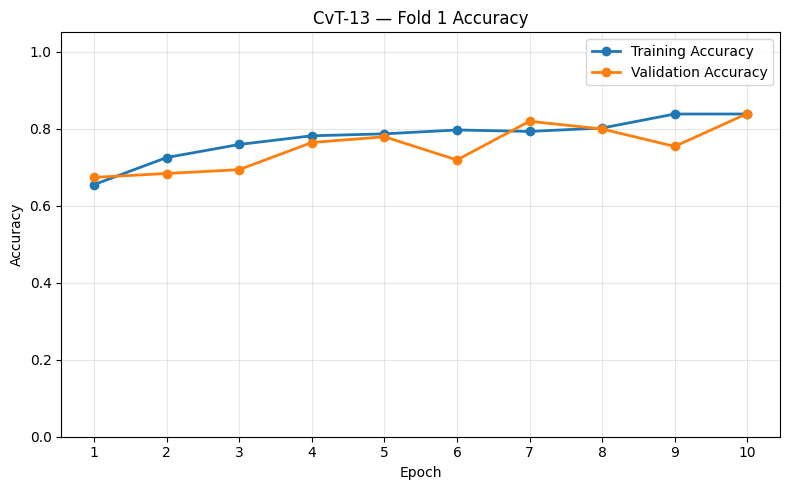

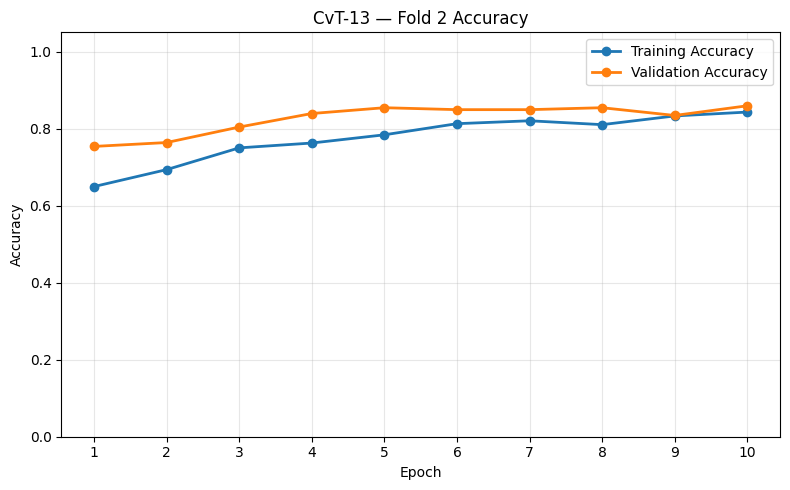

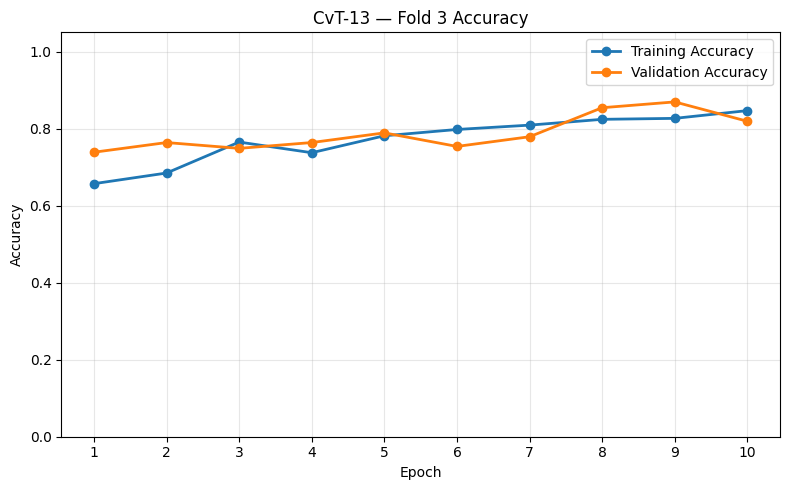

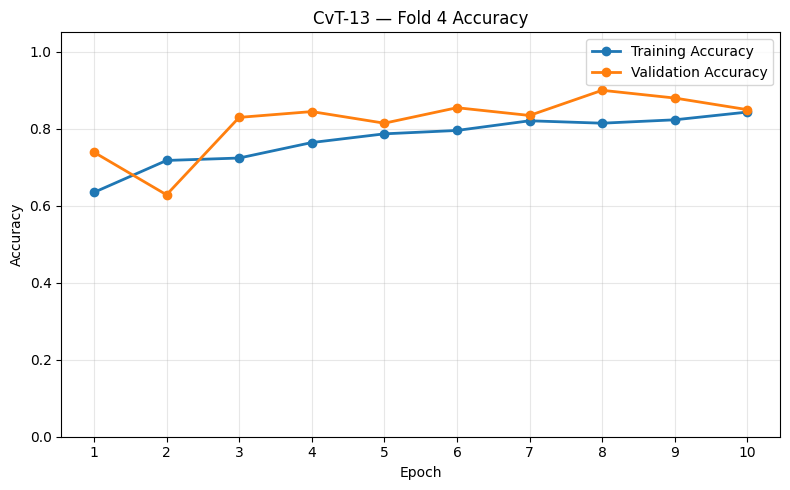

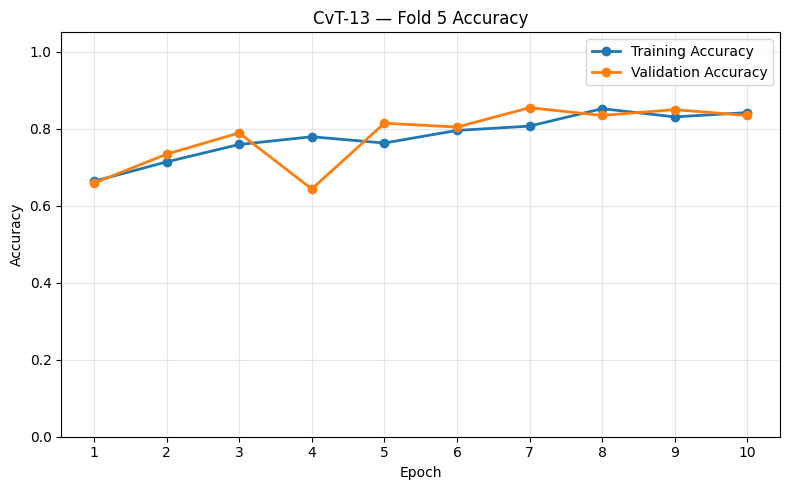

All available fold accuracy graphs displayed.


In [30]:
# ============================================================
# ACCURACY GRAPHS — SEPARATE GRAPH FOR EACH FOLD
# FIXED FOR LIST-BASED fold_histories
# ============================================================

import matplotlib.pyplot as plt

print("=" * 70)
print("5-FOLD TRAINING / VALIDATION ACCURACY GRAPHS")
print("=" * 70)

for fold_idx, history in enumerate(fold_histories, start=1):

    train_acc = history["train_acc"]
    val_acc   = history["val_acc"]

    epochs = range(1, len(train_acc) + 1)

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        train_acc,
        marker="o",
        linewidth=2,
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        val_acc,
        marker="o",
        linewidth=2,
        label="Validation Accuracy"
    )

    plt.title(
        f"CvT-13 — Fold {fold_idx} Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.ylim(0, 1.05)
    plt.xticks(list(epochs))

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()
    plt.show()

print("=" * 70)
print("All available fold accuracy graphs displayed.")
print("=" * 70)

5-FOLD TRAINING / VALIDATION LOSS GRAPHS


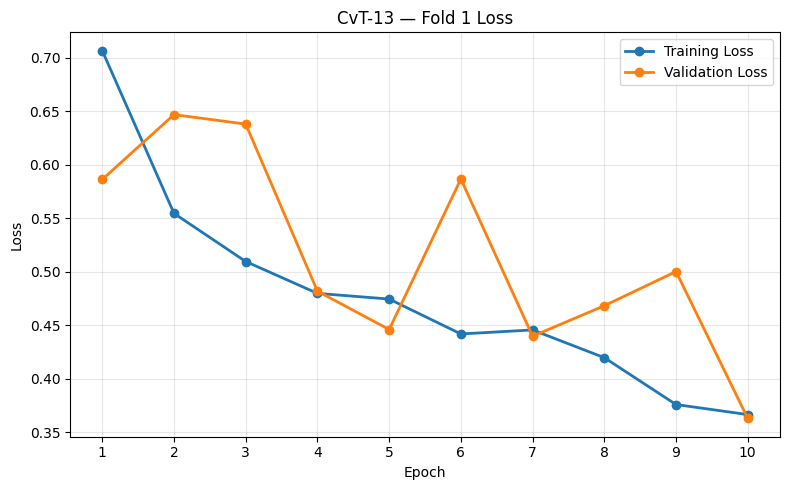

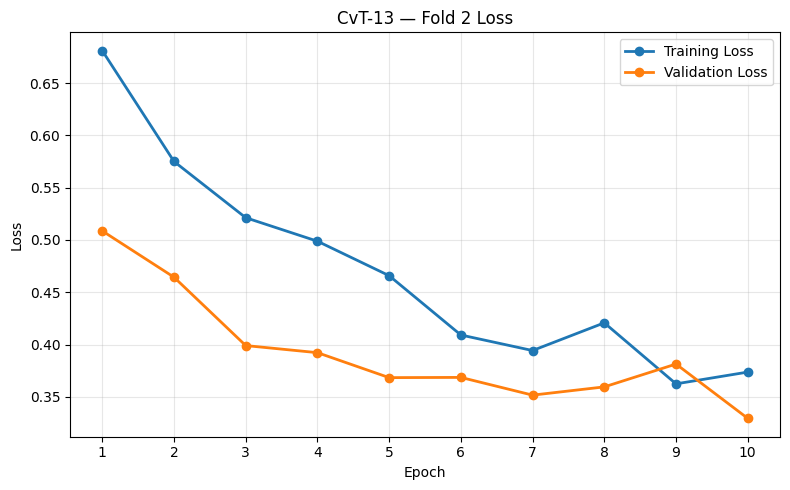

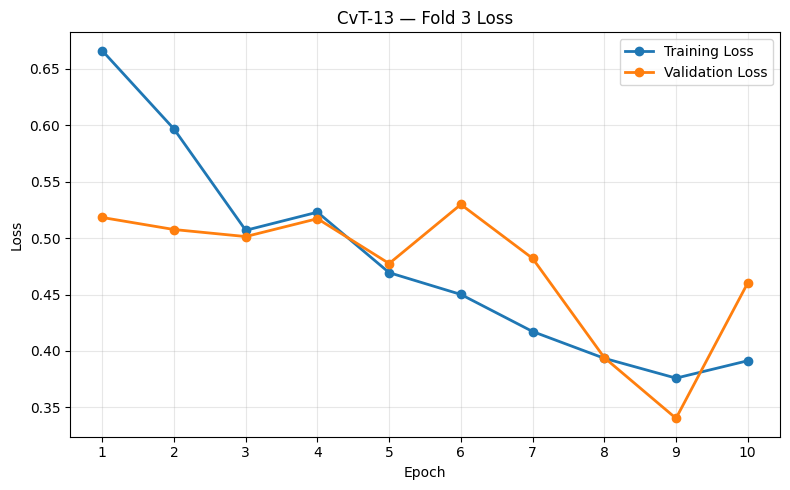

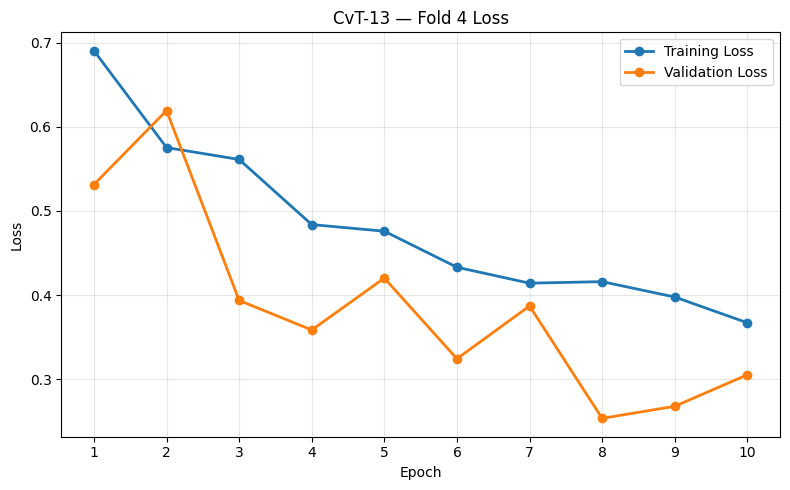

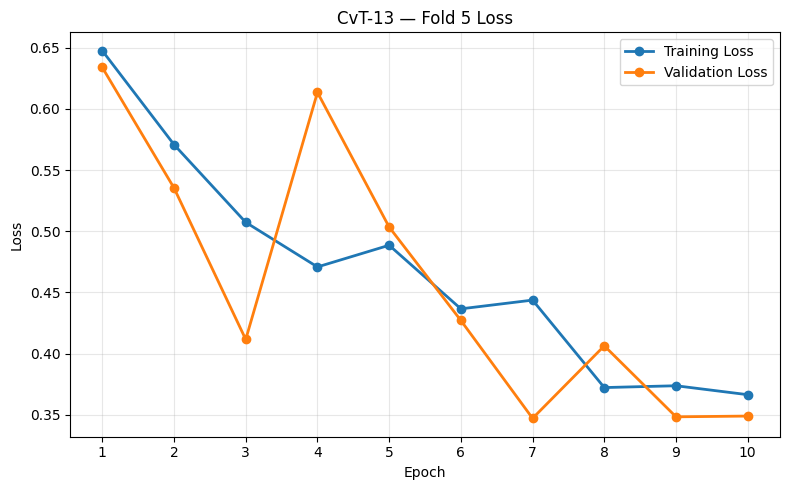

All available fold loss graphs displayed.


In [31]:
# ============================================================
# LOSS GRAPHS — SEPARATE GRAPH FOR EACH FOLD
# ============================================================

import matplotlib.pyplot as plt

print("=" * 70)
print("5-FOLD TRAINING / VALIDATION LOSS GRAPHS")
print("=" * 70)

for fold_idx, history in enumerate(fold_histories, start=1):

    train_loss = history["train_loss"]
    val_loss   = history["val_loss"]

    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        train_loss,
        marker="o",
        linewidth=2,
        label="Training Loss"
    )

    plt.plot(
        epochs,
        val_loss,
        marker="o",
        linewidth=2,
        label="Validation Loss"
    )

    plt.title(
        f"CvT-13 — Fold {fold_idx} Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.xticks(list(epochs))

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

print("=" * 70)
print("All available fold loss graphs displayed.")
print("=" * 70)

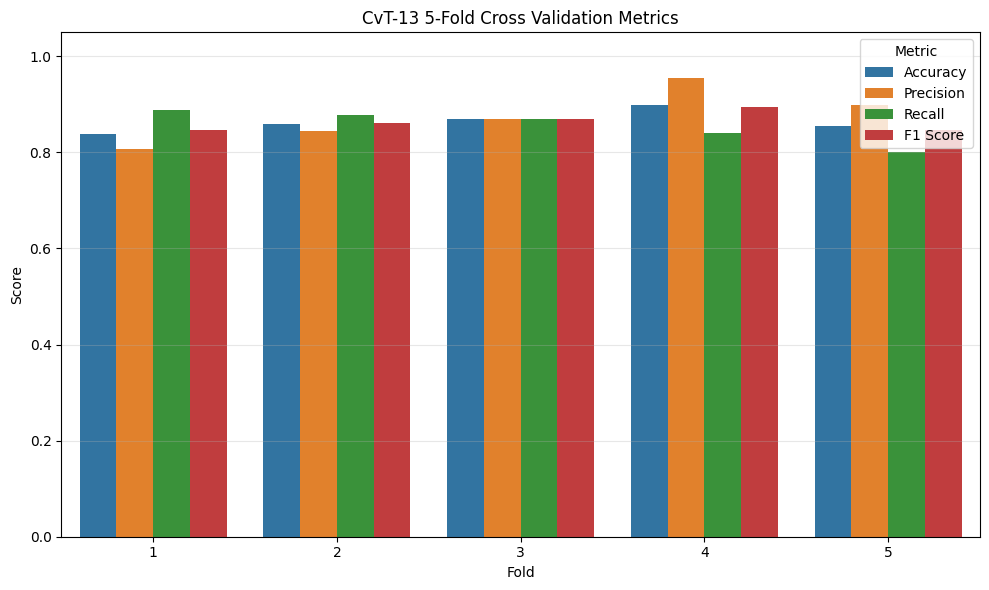

In [24]:
# 20. Fold-wise metric comparison
plot_df = results_df.melt(
    id_vars="Fold",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="Fold", y="Score", hue="Metric")
plt.title("CvT-13 5-Fold Cross Validation Metrics")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


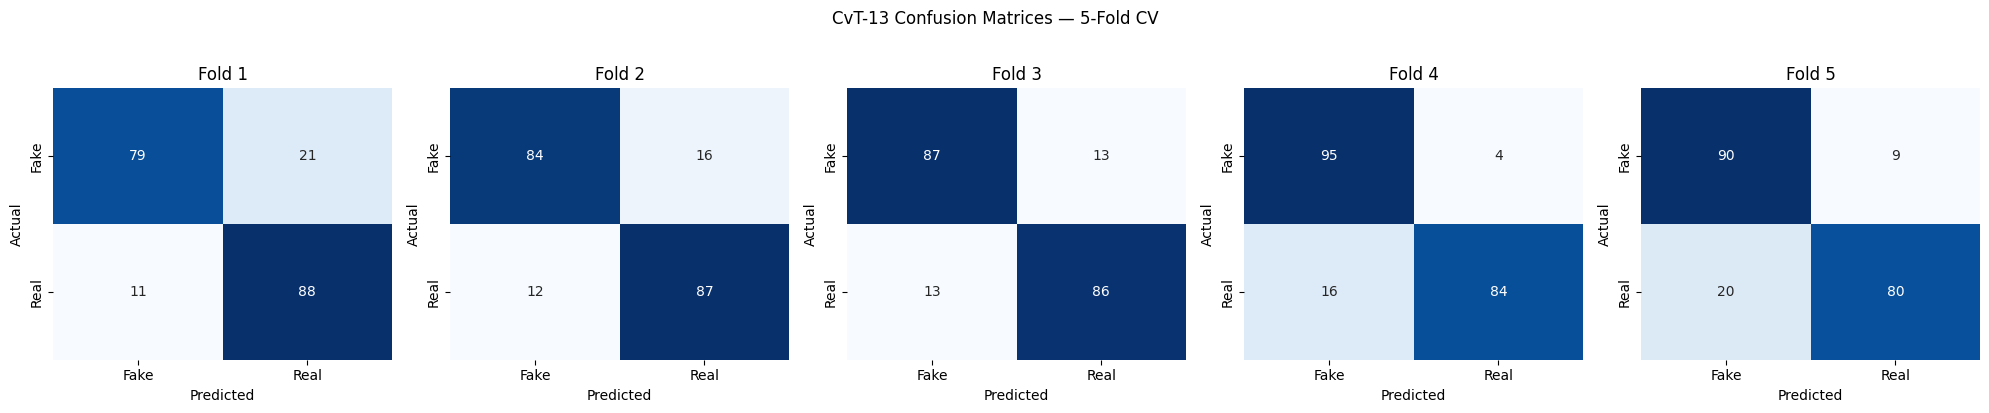

In [25]:
# 21. Confusion matrices
fig, axes = plt.subplots(1, N_SPLITS, figsize=(4 * N_SPLITS, 4))

if N_SPLITS == 1:
    axes = [axes]

for i, cm in enumerate(fold_confusion_matrices):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[i],
        xticklabels=["Fake", "Real"],
        yticklabels=["Fake", "Real"]
    )
    axes[i].set_title(f"Fold {i+1}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.suptitle("CvT-13 Confusion Matrices — 5-Fold CV", y=1.02)
plt.tight_layout()
plt.show()


In [26]:
# 22. Final summary
best_fold = int(results_df.loc[results_df["Accuracy"].idxmax(), "Fold"])

print("=" * 70)
print("FINAL CvT-13 5-FOLD CROSS VALIDATION SUMMARY")
print("=" * 70)

for col in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    mean = results_df[col].mean()
    std = results_df[col].std(ddof=1)
    print(f"{col:10s}: {mean:.4f} ± {std:.4f}")

print("\nBest validation fold:", best_fold)
print(
    "Best fold accuracy:",
    f"{results_df.loc[results_df['Fold'] == best_fold, 'Accuracy'].iloc[0]:.4f}"
)

print("\nSaved model directory:")
print("/content/cvt13_fold_models/")


FINAL CvT-13 5-FOLD CROSS VALIDATION SUMMARY
Accuracy  : 0.8643 ± 0.0225
Precision : 0.8748 ± 0.0558
Recall    : 0.8553 ± 0.0359
F1 Score  : 0.8633 ± 0.0195

Best validation fold: 4
Best fold accuracy: 0.8995

Saved model directory:
/content/cvt13_fold_models/
